## IronKaggle - mini project

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Read data

In [148]:
sales_df = pd.read_csv('sales.csv')
sales_df

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882
...,...,...,...,...,...,...,...,...,...,...
640835,359783,409,6,2013-10-26,483,1,0,0,0,4553
640836,152315,97,1,2014-04-14,987,1,1,0,0,12307
640837,117952,987,1,2014-07-07,925,1,0,0,0,6800
640838,435829,1084,4,2014-06-12,725,1,0,0,0,5344


### EDA

In [4]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB


In [21]:
sales_df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [41]:
# Unique values in each column
for i in sales_df.columns:
    print(i, ' : ', sales_df[i].nunique())

Unnamed: 0  :  640840
store_ID  :  1115
day_of_week  :  7
date  :  942
nb_customers_on_day  :  3886
open  :  2
promotion  :  2
state_holiday  :  4
school_holiday  :  2
sales  :  20129


In [47]:
sales_df.isna().sum()

store_ID               0
day_of_week            0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
year                   0
month                  0
day                    0
dtype: int64

In [ ]:
sales_df.state_holiday.value_counts(normalize=True)

state_holiday
0    621160
a     12842
b      4214
c      2624
Name: count, dtype: int64

## Notes

- Drop First column (Unamed:0) when reading the file. Could be indices.
- `store_ID` : Unique ids of the shop. Hass 1115 unique values. Numerical values could be indicate a relation or order between the stores. Could be dropped but we might loss some information about the shop.
- There are two columns with datatypes str, which need to be converted to numerical type.
  - `state_holiday` is a ctegorical column with 4 categories. One-Hot encoding needed.
- `day_of_week` is a categorical column with ordinal values. We can keep the ordinal values as the days of a week are related and sequence of the days in a week do not change. No change required for this column.
-  Convaert date format into thre columns of year, month and date.
-  No missing values

In [149]:
# Drop the Unamed column
sales_df.drop(columns='Unnamed: 0', inplace=True)

#convert object date column to Date time
sales_df['date'] = pd.to_datetime(sales_df['date'])
# Split the date column using dt accessor
sales_df['year'] = sales_df['date'].dt.year
sales_df['month'] = sales_df['date'].dt.month
sales_df['day'] = sales_df['date'].dt.day

# drop the date column
sales_df.drop(columns='date', inplace=True)

sales_df

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month,day
0,366,4,517,1,0,0,0,4422,2013,4,18
1,394,6,694,1,0,0,0,8297,2015,4,11
2,807,4,970,1,1,0,0,9729,2013,8,29
3,802,2,473,1,1,0,0,6513,2013,5,28
4,726,4,1068,1,1,0,0,10882,2013,10,10
...,...,...,...,...,...,...,...,...,...,...,...
640835,409,6,483,1,0,0,0,4553,2013,10,26
640836,97,1,987,1,1,0,0,12307,2014,4,14
640837,987,1,925,1,0,0,0,6800,2014,7,7
640838,1084,4,725,1,0,0,0,5344,2014,6,12


In [150]:
sales_df[sales_df['open'] == 0]

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month,day
6,659,7,0,0,0,0,0,0,2014,6,8
10,273,7,0,0,0,0,0,0,2014,10,5
18,767,7,0,0,0,0,0,0,2013,1,27
34,534,7,0,0,0,0,0,0,2014,6,8
35,514,7,0,0,0,0,0,0,2014,3,9
...,...,...,...,...,...,...,...,...,...,...,...
640807,167,7,0,0,0,0,0,0,2014,7,27
640812,870,3,0,0,0,0,1,0,2014,7,23
640814,650,7,0,0,0,0,0,0,2014,3,23
640834,329,7,0,0,0,0,0,0,2013,9,15


<Axes: >

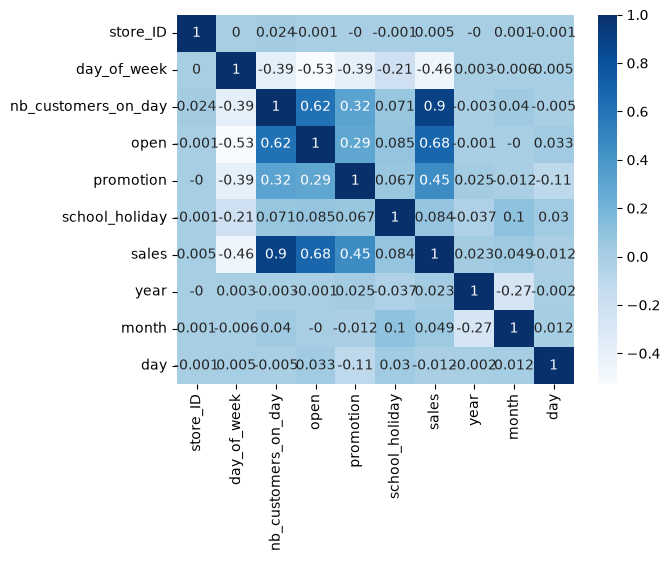

In [58]:
corr_df = sales_df.drop(columns=['state_holiday']).corr().round(3)
sns.heatmap(corr_df, cmap='Blues', annot=True)

- There is not much correlation between the features
- We can notice correlation between the sales (target) and the features. This is a good indication. This means that these features are important for the sales.

In [ ]:
for i in sales_df.columns:
    sns.histplot(sales_df[i])
    plt.show()

In [ ]:
sales_df[sales_df['open'] == 0].describe()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales,year,month,day
count,108824.000000,108824.000000,108824.0,108824.0,108824.000000,108824.000000,108824.0,108824.000000,108824.000000,108824.000000
mean,558.999577,6.330717,0.0,0.0,0.064912,0.106328,0.0,2013.834310,5.847304,15.062780
std,323.172967,1.549876,0.0,0.0,0.246372,0.308258,0.0,0.778382,3.339083,9.267937
min,1.000000,1.000000,0.0,0.0,0.000000,0.000000,0.0,2013.000000,1.000000,1.000000
25%,279.000000,7.000000,0.0,0.0,0.000000,0.000000,0.0,2013.000000,3.000000,7.000000
50%,561.000000,7.000000,0.0,0.0,0.000000,0.000000,0.0,2014.000000,5.000000,15.000000
75%,839.000000,7.000000,0.0,0.0,0.000000,0.000000,0.0,2014.000000,8.000000,23.000000
max,1115.000000,7.000000,0.0,0.0,1.000000,1.000000,0.0,2015.000000,12.000000,31.000000


In [ ]:
sales_df[sales_df['open'] == 1].describe()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales,year,month,day
count,532016.000000,532016.000000,532016.000000,532016.0,532016.000000,532016.000000,532016.000000,532016.000000,532016.000000,532016.000000
mean,558.050115,3.523479,762.960407,1.0,0.446520,0.193229,6959.251679,2013.831951,5.846401,15.844424
std,321.613167,1.723849,400.736508,0.0,0.497132,0.394832,3105.241710,0.777121,3.323564,8.684478
min,1.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,2013.000000,1.000000,1.000000
25%,280.000000,2.000000,519.000000,1.0,0.000000,0.000000,4861.000000,2013.000000,3.000000,8.000000
50%,558.000000,3.000000,676.000000,1.0,0.000000,0.000000,6372.000000,2014.000000,6.000000,16.000000
75%,836.000000,5.000000,893.000000,1.0,1.000000,0.000000,8365.000000,2014.000000,8.000000,23.000000
max,1115.000000,7.000000,5458.000000,1.0,1.000000,1.000000,41551.000000,2015.000000,12.000000,31.000000


In [ ]:
sales_df.describe()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales,year,month,day
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011,2013.832351,5.846555,15.711689
std,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083,0.777335,3.326202,8.791182
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,1.000000
25%,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000,2013.000000,3.000000,8.000000
50%,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000,2014.000000,6.000000,16.000000
75%,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000,2014.000000,8.000000,23.000000
max,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000,2015.000000,12.000000,31.000000


In [102]:
sales_df.open.value_counts(normalize=True)

open
1    0.830185
0    0.169815
Name: proportion, dtype: float64

- The distribution of values for each features suggests that sales and number of customers where 0 when the store was closed.
- Looking at the descriptive statistics for both caes (open and closed store), we see a difference in the values.
- It is safe to infer that when the store is closed there are no sale, so when can drop the rows when the store was open. Also, we can see that the store was closed for ~17% of the time.

In [107]:
sales_df = sales_df[sales_df['open'] == 1].drop(columns='open')
sales_df.shape

(532016, 10)

In [ ]:
sales_df.state_holiday.value_counts(normalize=True)

## Data splitting

In [45]:
from sklearn.model_selection import train_test_split


In [125]:
# Extract the data in features and target
X = sales_df.drop(columns='sales')
y = sales_df['sales']

In [134]:
# Split data into Train, Validation, Test sets (70, 15, 15)
# first split: train (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Check the size of each split
print('X_train shape:', X_train.shape)
print('X_val shape:  ', X_val.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (372411, 9)
X_val shape:   (79802, 9)
X_test shape:  (79803, 9)


## Data cleaning

In [ ]:
X_train[X_train['state_holiday'] != 0]

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,year,month,day


## Feature engineering

In [64]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [135]:
# Features to transform
categorical_features = ['state_holiday']
continuous_features  = ['store_ID', 'nb_customers_on_day']

# Encoding categorical values
encoder = OneHotEncoder(drop='first', sparse_output=False)
# Scaling continuous numerical values
scaler = StandardScaler()


In [136]:
# Fit on training data only, then apply the same encoding to all splits.
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_val_encoded = encoder.transform(X_val[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

# Get the generated column names
encoded_feature_names = encoder.get_feature_names_out().tolist()

# Wrap encoded arrays back into DataFrames, preserving original indices
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_val_encoded_df = pd.DataFrame(X_val_encoded, columns=encoded_feature_names, index=X_val.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

In [137]:
# Fit on training data only, then apply scaling to all splits.
X_train_scaled = scaler.fit_transform(X_train[continuous_features])
X_val_scaled = scaler.transform(X_val[continuous_features])
X_test_scaled = scaler.transform(X_test[continuous_features])

# Get the generated column names
scaled_feature_names = scaler.get_feature_names_out().tolist()

# Wrap scaled arrays back into DataFrames, preserving original indices
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=scaled_feature_names, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=scaled_feature_names, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=scaled_feature_names, index=X_test.index)

In [124]:
X_train_scaled_df

,store_ID,nb_customers_on_day
30784,-1.370994,-0.669039
193456,-1.032106,0.363803
369422,-0.198877,0.528062
160551,0.329663,-0.517223
438196,-1.548211,-0.315633
...,...,...
132892,1.557743,1.274694
312403,-0.152241,-0.589398
440711,0.976349,0.291628
159001,0.205301,-0.036890


In [145]:
sales_df.state_holiday.value_counts(normalize=True)

state_holiday
0    0.998912
a    0.000806
b    0.000192
c    0.000090
Name: proportion, dtype: float64

In [146]:
sales_df.school_holiday.value_counts(normalize=True)

school_holiday
0    0.806771
1    0.193229
Name: proportion, dtype: float64

In [ ]:
from sklearn.dummy import DummyRegressor

avg_sales = y_train.mean()
print('Average total sales in train set: ', avg_sales)

baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train, y_train)

Average total sales in train set:  6957.196551659323


,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[6957.2]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](9,)","['store_ID','day_of_week','nb_customers_on_day',...,'year','month','day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,9
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def evaluate_classifier(model, model_name, X_train, y_train, X_val, y_val):

    # Train the model on the training data (ignore returned fitted model)
    _ = model.fit(X_train, y_train)

    # Compute the predictions on training and validation sets
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    return {
        'model': model_name,
        'MAE' : mean_absolute_error(y_val, y_val_pred),
        #'MSE' : mean_squared_error(y_val, y_val_pred),
        'RMSE' : root_mean_squared_error(y_val, y_val_pred),
        'r2_train': r2_score(y_train, y_train_pred),
        'r2_val': r2_score(y_val, y_val_pred)
    }

In [133]:
baseline_evaluted = evaluate_classifier(baseline_model, 'Baseline Model', X_train, y_train, X_val, y_val)
baseline_evaluted

{'model': 'Baseline Model',
 'MAE': 2294.7679827285833,
 'MSE': 9719788.608911132,
 'RMSE': 3117.657551577968,
 'r2_train': 0.0,
 'r2_val': -9.614512022082522e-06}

In [142]:
baseline_evaluted = evaluate_classifier(baseline_model, 'Baseline Model', X_train, y_train, X_val, y_val)
baseline_evaluted

{'model': 'Baseline Model',
 'MAE': 2240.7424375328937,
 'MSE': 10075941.210972156,
 'RMSE': 3174.262309729956,
 'r2_train': -0.03577089539487721,
 'r2_val': -0.036651977903338295}